In [126]:
import torch
from torchvision import transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
from darts_model import CNNTransformer


In [127]:
arr = np.zeros(5)
idx = np.array([0,0,1])
arr[idx] += 1
arr

array([1., 1., 0., 0., 0.])

In [128]:
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
    transforms.Resize(512),  # ResNet-50 expects 224x224 images
    transforms.CenterCrop(512),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

In [129]:
# _transform = transforms.Compose([
#     transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
#     transforms.Resize(224),  # ResNet-50 expects 224x224 images
#     transforms.CenterCrop(224),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
#                          std=[0.229, 0.224, 0.225])   # ImageNet std
# ])

In [ ]:
filename = "3D/imgs_0014/img_0013.png"
# filename="thommy/IMG_9420.jpg"

In [131]:
image = cv2.imread(filename, cv2.IMREAD_COLOR_RGB)
image_transformed = transform(image)

In [132]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
query_dim = 256
model = CNNTransformer(d=query_dim).to(device)
model.load_state_dict(torch.load("models/epoch_50_0.0250_0.0348_0.0576_1.0000.pt", weights_only=True))

C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

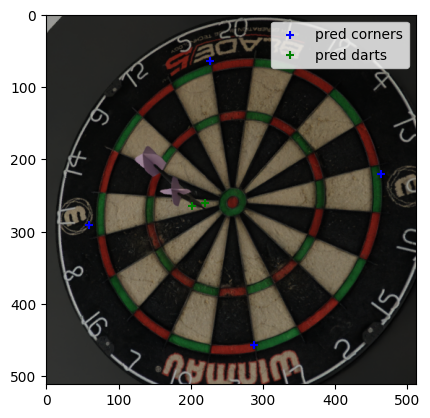

In [134]:
model.eval()
# image, targets = dataset[idx]
images = image_transformed.unsqueeze(0).to(device)
# targets = [targets]
w, h, _ = image.shape      
outputs = model(images)
pred_classes = torch.argmax(outputs["is_dart"], dim=-1)

fig, ax = plt.subplots(1)
ax.imshow(transforms.ToTensor()(image).permute(1,2,0))


pred_corners = outputs["corners"][0].cpu().detach()
pred_darts = outputs["darts"][0][outputs["is_dart"][0, :, 1] > outputs["is_dart"][0, :, 0]].cpu().detach()
all_darts = outputs["darts"][0].cpu().detach()

# Draw points
ax.scatter(pred_corners[:, 0]*w, pred_corners[:, 1]*h, color='blue', s=40, marker='+', label="pred corners")
# ax.scatter(all_darts[:, 0]*w, all_darts[:, 1]*h, color='white', s=10, marker='x', label="all darts")
ax.scatter(pred_darts[:, 0]*w, pred_darts[:, 1]*h, color='green', s=40, marker='+', label="pred darts")
# ax.scatter(targets[0]["corners"][:, 0]*w, targets[0]["corners"][:, 1]*h, color='blue', s=10, marker='o', label="gt corners")
# ax.scatter(targets[0]["darts"][:, 0]*w, targets[0]["darts"][:, 1]*h, color='red', s=10, marker='o', label="gt darts")

# Show plot
plt.legend()
plt.show()